### Feature Matching
in this notebook we would like to experiment with using opencv for feature mappping on a set of images

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import kornia as K
import kornia.feature as KF
import torch
from kornia_moons.viz import draw_LAF_matches
from kornia.feature import LoFTR

/home/kaarl/miniconda3/envs/computer-vision/lib/python3.8/site-packages/kornia/feature/lightglue.py:44: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)


brute force featrure matching with the SIFT detector

In [2]:
sift = cv2.SIFT_create()

In [3]:
root_dir = '/home/kaarl/Developer/ai-learning-journey/cv-course/sample_images_dataset'


In [9]:

img1 = cv2.imread(f'{root_dir}/birds/bird1.jpeg')
img2 = cv2.imread(f'{root_dir}/birds/bird2.jpg')

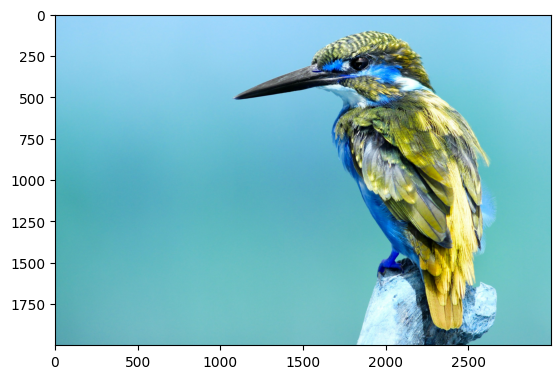

In [10]:
plt.imshow(img1)
plt.show()

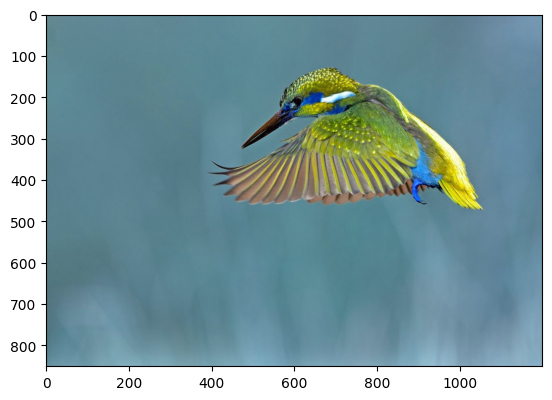

In [12]:
plt.imshow(img2)
plt.show()


In [13]:
kp1, des1 = sift.detectAndCompute(img1, None)
kp2, des2 = sift.detectAndCompute(img2, None)

In [14]:
bf = cv2.BFMatcher()
matches = bf.knnMatch(des1, des2, k=2)

In [15]:
good = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good.append([m])

In [16]:
img3 = cv2.drawMatchesKnn(
    img1, kp1, img2, kp2, good, None, 
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

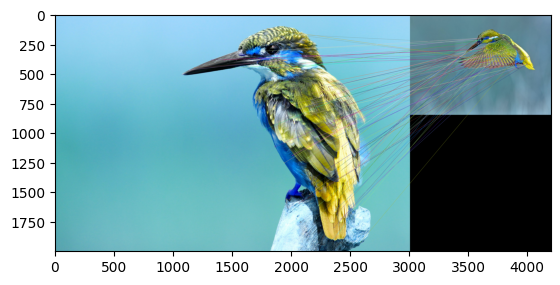

In [17]:
plt.imshow(img3)
plt.show()

Brute force with ORB(binary) descriptors

In [18]:
orb = cv2.ORB_create()

In [19]:
kp1, des1 = orb.detectAndCompute(img1, None)
kp2, des2 = orb.detectAndCompute(img2, None)

In [20]:
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

In [21]:
matches = bf.match(des1, des2)

In [22]:
matches = sorted(matches, key=lambda x: x.distance)

In [23]:
n

< cv2.DMatch 0x7f9d7ff0d990>

In [24]:
img4 = cv2.drawMatches(
    img1, kp1, img2, kp2, matches, None, 
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)



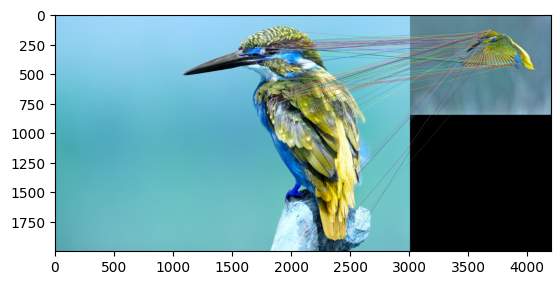

In [25]:
plt.imshow(img4)
plt.show()

In [26]:
FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)

In [27]:
FLANN_INDEX_LSH = 6
index_params = dict(
    algorithm=FLANN_INDEX_LSH,
    table_number=12, 
    key_size=20, 
    multi_probe_level=2
)

In [28]:
search_params = dict(checks=50)

In [29]:
kp1, des1 = sift.detectAndCompute(img1, None)
kp2, des2 = sift.detectAndCompute(img2, None)

In [30]:
FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
search_params = dict(checks=50)
flann = cv2.FlannBasedMatcher(index_params, search_params)
matches = flann.knnMatch(des1, des2, k=2)

In [31]:
matchesMask = [[0, 0] for i in range(len(matches))]

In [32]:
for i, (m, n) in enumerate(matches):
    if m.distance < 0.75 * n.distance:
        matchesMask[i] = [1, 0]

In [33]:
draw_params = dict(
    matchColor=(0, 255, 0),
    singlePointColor=(255, 0, 0),
    matchesMask=matchesMask,
    flags=cv2.DrawMatchesFlags_DEFAULT
)

img5 = cv2.drawMatchesKnn(
    img1, kp1, img2, kp2, matches, None, **draw_params
)

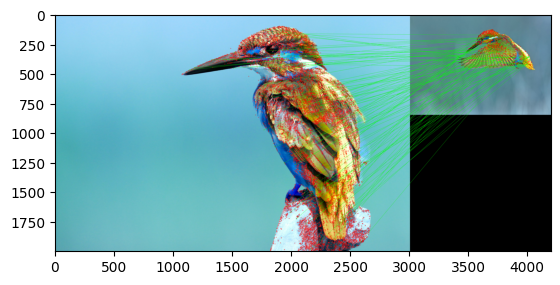

In [34]:
plt.imshow(img5)
plt.show()

In [2]:
root_dir = '/home/kaarl/Developer/ai-learning-journey/cv-course/sample_images_dataset'

[ WARN:0@209.009] global loadsave.cpp:275 findDecoder imread_('/home/kaarl/Developer/ai-learning-journey/cv-course/sample_images_dataset/birds/bird2.jpeg'): can't open/read file: check file path/integrity


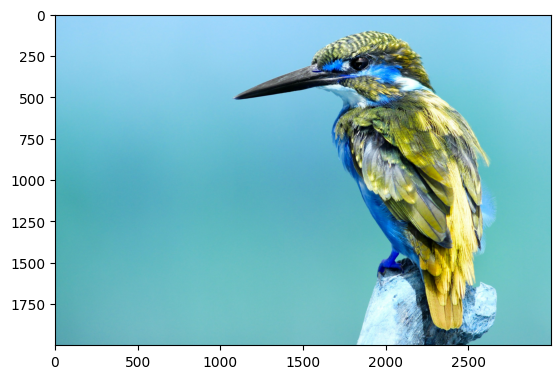

In [ ]:
img1 = cv2.imread(f'{root_dir}/birds/bird1.jpeg')
img2 = cv2.imread(f'{root_dir}/birds/bird2.jpg')

plt.imshow(img1)
plt.show()

In [5]:
img1 = K.io.load_image(f'{root_dir}/birds/bird1.jpeg', K.io.ImageLoadType.RGB32)[None, ...]
img2 = K.io.load_image(f'{root_dir}/birds/bird2.jpg', K.io.ImageLoadType.RGB32)[None, ...]

In [6]:
img1 = K.geometry.resize(img1, (512, 512))
img2 = K.geometry.resize(img2, (512, 512))

In [9]:
matcher = LoFTR(pretrained="outdoor")

Downloading: "http://cmp.felk.cvut.cz/~mishkdmy/models/loftr_outdoor.ckpt" to /home/kaarl/.cache/torch/hub/checkpoints/loftr_outdoor.ckpt
100%|██████████| 44.2M/44.2M [00:08<00:00, 5.48MB/s]


In [10]:
input_dict = {
    "image0":K.color.rgb_to_grayscale(img1),
    "image1":K.color.rgb_to_grayscale(img2),
}


In [11]:
with torch.inference_mode():
    correspondences = matcher(input_dict)


In [12]:
mkpts0 = correspondences["keypoints0"].cpu().numpy()
mkpts1 = correspondences["keypoints1"].cpu().numpy()

Fm, inliers = cv2.findFundamentalMat(mkpts0, mkpts1, cv2.USAC_MAGSAC, 0.5, 0.999, 100000)
inliers = inliers > 0

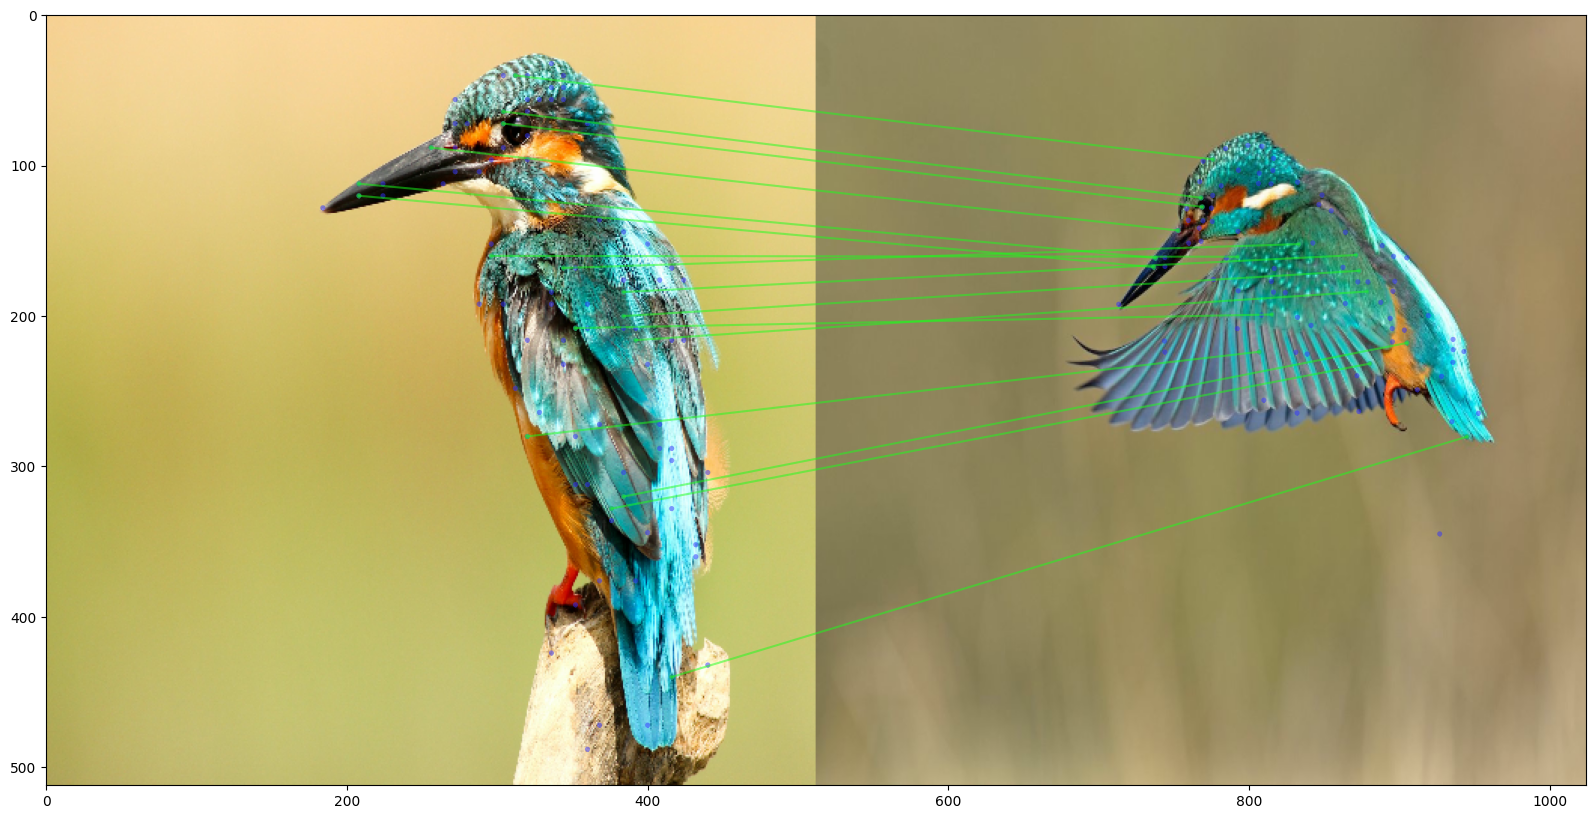

In [16]:
draw_LAF_matches(
    KF.laf_from_center_scale_ori(
        torch.from_numpy(mkpts0).view(1, -1, 2),
        torch.ones(mkpts0.shape[0]).view(1, -1, 1, 1),
        torch.ones(mkpts0.shape[0]).view(1, -1, 1)
        ),

    KF.laf_from_center_scale_ori(
        torch.from_numpy(mkpts1).view(1, -1, 2),
        torch.ones(mkpts1.shape[0]).view(1, -1, 1, 1),
        torch.ones(mkpts1.shape[0]).view(1, -1, 1),
    ),
    torch.arange(mkpts0.shape[0]).view(-1, 1).repeat(1, 2),
    K.tensor_to_image(img1),
    K.tensor_to_image(img2),
    inliers,
    draw_dict={
        "inlier_color": (0.1, 1, 0.1, 0.5),
        "tentative_color": None,
        "feature_color": (0.2, 0.2, 1, 0.5),
        "vertical": False,
    },
)